## Machine Learning for Healthcare

## Segment Patients with Clustering & AI Assistance

Imagine you are managing a healthcare organization. It does not matter if you run
a small clinic or a large hospital network. It does not matter if it is a local
practice or a major health system — it is better to **know your patients**.

Machine learning comes in handy for this task. Particularly, **clustering**, the
most important unsupervised learning problem, is able to create categories
grouping similar individuals.

These categories are called **clusters**. A cluster is a collection of points in
a dataset. These points are more similar between them than they are to points
belonging to other clusters.

**Distance-based clustering** groups the points into some number of clusters such
that distances within the cluster should be small while distances between clusters
should be large.

In this session, you'll learn to segment patients into meaningful groups using
clustering. Along the way, you'll practice:

- Writing prompts to generate clustering code with AI
- Exploring and preparing real-world healthcare data
- Understanding why algorithm choice matters for mixed data
- Correcting the AI when it suggests the wrong approach

**Dataset:**
[Patient Segmentation Dataset (Kaggle)](https://www.kaggle.com/) — 2,000 patient
records with demographics, clinical conditions, insurance, and visit information.

##  Enhancing Patient Engagement and Resource Optimization through Advanced Segmentation

**Challenge:** In today's dynamic healthcare landscape, organizations face an imperative to move beyond generalized patient care towards personalized, data-driven strategies. A fundamental challenge lies in effectively understanding the diverse needs and characteristics within their patient populations. Without granular insights into patient cohorts, healthcare providers struggle to optimize resource allocation, tailor interventions, and deliver the most impactful care.

**Proposed Solution:** This initiative leverages advanced machine learning, specifically patient segmentation through clustering, to systematically categorize individuals based on their demographic, clinical, and behavioral attributes. By grouping similar patients into distinct 'clusters', we can uncover underlying patterns and create actionable profiles.

**Expected Benefits:**
*   **Enhanced Patient Understanding:** Gain deep insights into different patient segments, enabling a more nuanced approach to care.
*   **Optimized Resource Allocation:** Strategically deploy resources (e.g., specialized programs, staff, facilities) to meet the specific needs of identified patient groups.
*   **Targeted Interventions:** Develop and implement highly effective, personalized care plans and communication strategies for each segment.
*   **Improved Patient Outcomes:** Drive better health outcomes and patient satisfaction by addressing the unique drivers of health and disease within each segment.
*   **Strategic Decision-Making:** Provide leadership with robust data-driven insights to inform operational, clinical, and strategic planning, fostering a more proactive and efficient healthcare delivery model.

## 1. Setup & Imports

I'm going to work with a CSV dataset for data exploration, visualization, and clustering. Import everything I need for data manipulation, statistical summaries, static and interactive charts, and machine learning preprocessing.

In [4]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Statistical summaries
from scipy import stats

# Visualization (static and interactive)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Display settings for pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# For displaying multiple outputs in a cell
from IPython.display import display

## 2. Load & Explore the Dataset

In [5]:
patient_insurance_df = pd.read_csv('patient_insurance_dataset.csv')
patient_insurance_df.head()

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


Show shape, data types and a statistical summary of the patient_ot_df DataFrame. Also show the value counts for all categorical columns. Add only code block. Do not add markdown cells.

In [7]:
# Show shape
print('Shape:', patient_insurance_df.shape)

# Show data types
print('\nData Types:')
print(patient_insurance_df.dtypes)

# Show statistical summary (include all columns)
display(patient_insurance_df.describe(include='all'))

# Show value counts for all categorical columns
categorical_cols = patient_insurance_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    display(patient_insurance_df[col].value_counts())

Shape: (2000, 16)

Data Types:
PatientID                  object
Age                         int64
Gender                     object
State                      object
City                       object
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type             object
Primary_Condition          object
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date            object
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
count,2000,2000.00000,2000,2000,2000,2000.000000,2000.000000,2000.000000,2000,1505,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,2000,NaN,2,10,20,NaN,NaN,NaN,4,9,NaN,NaN,NaN,364,NaN,NaN
top,P11983,NaN,Female,NC,Unknown,NaN,NaN,NaN,Medicare,Hypertension,NaN,NaN,NaN,2025-07-03,NaN,NaN
freq,1,NaN,1001,213,1012,NaN,NaN,NaN,906,210,NaN,NaN,NaN,13,NaN,NaN
mean,NaN,50.69550,NaN,NaN,NaN,167.907500,85.143500,30.740650,NaN,NaN,1.080000,5.466500,4000.270500,NaN,180.085000,0.464000
std,NaN,15.44445,NaN,NaN,NaN,12.684494,20.385428,8.839952,NaN,NaN,0.890504,3.485965,2463.239215,NaN,104.688484,0.498827
min,NaN,18.00000,NaN,NaN,NaN,145.000000,50.000000,13.400000,NaN,NaN,0.000000,1.000000,207.000000,NaN,1.000000,0.000000
25%,NaN,40.00000,NaN,NaN,NaN,158.000000,67.000000,23.800000,NaN,NaN,1.000000,3.000000,2061.000000,NaN,90.000000,0.000000
50%,NaN,51.00000,NaN,NaN,NaN,168.000000,86.000000,30.100000,NaN,NaN,1.000000,4.000000,3707.250000,NaN,183.000000,0.000000
75%,NaN,63.25000,NaN,NaN,NaN,177.000000,103.000000,37.025000,NaN,NaN,1.000000,8.000000,5650.875000,NaN,268.000000,1.000000



Value counts for PatientID:


,count
PatientID,
P11983,1
P11982,1
P11981,1
P11980,1
P11979,1
...,...
P10004,1
P10003,1
P10002,1



Value counts for Gender:


...

,count
Insurance_Type,
Medicare,906
Private,545
Medicaid,483
Self-Pay,66



Value counts for Primary_Condition:


,count
Primary_Condition,
Hypertension,210
Obesity,183
Anxiety,175
Arthritis,163
Asthma,160
Depression,160
Diabetes,158
Heart Disease,150
COPD,146



Value counts for Last_Visit_Date:


,count
Last_Visit_Date,
2025-07-03,13
2025-11-27,13
2025-07-15,12
2025-12-25,12
2025-09-24,12
...,...
2025-07-28,1
2025-09-25,1
2025-04-09,1


## 3. Data Cleaning

One of the things necessary is to determine whether you have missing values. Handling missing values is always difficult. If only a few observations are missing, they can be excluded. If there is a significant number of missing values, several options are available depending on the type of missing value.

But here's the catch: missing values don't always show up as `NaN`. Sometimes they hide as strings like `"Unknown"`, `"None"`, `"N/A"`, or even blank spaces. The AI or even Pandas won't flag these automatically. You need to check for them yourself.

### Check for missing values

Check for missing values in the patient_ot_df DataFrame.

In [9]:
# Check for missing (NaN) values in each column
missing_counts = patient_insurance_df.isna().sum()
missing_percent = (missing_counts / len(patient_insurance_df)) * 100

import pandas as pd
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary:')
display(missing_summary)

Missing values summary:


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,0,0.00
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


The AI tells us that the dataset doesn't have missing values. Is that correct?

You should re-check the actual values that you saw when we count the values in each column. Sometimes "missing" data hides behind placeholder strings.

If you look at the **City** column there are values recorded as "Unknown". Also, the **Primary condition** has "None" as a value. Pandas didn't flag these as missing because technically they're valid strings. But "Unknown" is not a real city. It's a disguised missing value.

This is a very common problem in real-world data, especially in healthcare. Missing data is sometimes filled with placeholder text like "Unknown", "None", "Not Specified", or "N/A" instead of leaving them as actual null values.

**The AI missed this.** It only checked for `NaN` values.

The values "None" and "Unknown" should be considered missing values. Check again for missing values in all the columns of patient_ot_df DataFrame. Save the data in a variable called df_with_na

In [11]:
import numpy as np

# Define placeholder values to consider as missing
missing_placeholders = ["Unknown", "None"]

# Replace placeholder values with np.nan
patient_ot_df_replaced = patient_insurance_df.replace(missing_placeholders, np.nan)

# Save the result in df_with_na
df_with_na = patient_ot_df_replaced.copy()

# Check for missing values again
missing_counts = df_with_na.isna().sum()
missing_percent = (missing_counts / len(df_with_na)) * 100

import pandas as pd
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent.round(2)
})

print('Missing values summary (including placeholders as missing):')
display(missing_summary)

Missing values summary (including placeholders as missing):


,Missing Count,Missing Percent
PatientID,0,0.00
Age,0,0.00
Gender,0,0.00
State,0,0.00
City,1012,50.60
Height_cm,0,0.00
Weight_kg,0,0.00
BMI,0,0.00
Insurance_Type,0,0.00
Primary_Condition,495,24.75


Now you can see the true picture of missing data. The City column has ~50% missing, which is very high to impute reliably.

Also, you can observe that the Primary Condition for 495 patients is missing. On a deeper analysis, you can see that when the primary condition is present it has a disease or health condition associated.

The DataFrame df_with_na has 495 missing values in Primary_Condition. When the condition is present, it always names a disease. So missing = no condition. Fill them with 'No Condition', save the new DataFrame in a varible called patient_df_nonan and verify.

In [12]:
# Fill missing values in 'Primary_Condition' with 'No Condition'
patient_df_nonan = df_with_na.copy()
patient_df_nonan['Primary_Condition'] = patient_df_nonan['Primary_Condition'].fillna('No Condition')

# Verify the replacement
missing_primary_condition = patient_df_nonan['Primary_Condition'].isna().sum()
unique_primary_conditions = patient_df_nonan['Primary_Condition'].unique()

print(f"Missing values in 'Primary_Condition' after filling: {missing_primary_condition}")
print(f"Unique values in 'Primary_Condition': {unique_primary_conditions}")

Missing values in 'Primary_Condition' after filling: 0
Unique values in 'Primary_Condition': ['Arthritis' 'Depression' 'Asthma' 'Hypertension' 'Anxiety' 'No Condition'
 'Heart Disease' 'Obesity' 'COPD' 'Diabetes']


## 4. Exploratory Data Analysis


It is important you should get descriptive statistics and distribution of each variable of interest. Looking into distributions and descriptive statistics allows us to understand our patient population and determine if we need to perform any data transformation before clustering.

- For numerical variables, you need visualizations that helps you understand the spread and potential outliers in each feature. Also, you need to understand correlations.

- For categorical variables, you need counts that gives you insight into the distribution of these categories in the dataset.

Create a grid of histograms with KDE curves for all numeric columns, count plots for the categorical columns Gender, Insurance_Type, and Primary_Condition, and a correlation heatmap for the numeric columns in the DataFrame patient_df_nonan. Use seaborn with the Set2 palette and coolwarm for the heatmap. Annotate the heatmap with correlation values and show only the lower triangle. Do not add markdown cells.

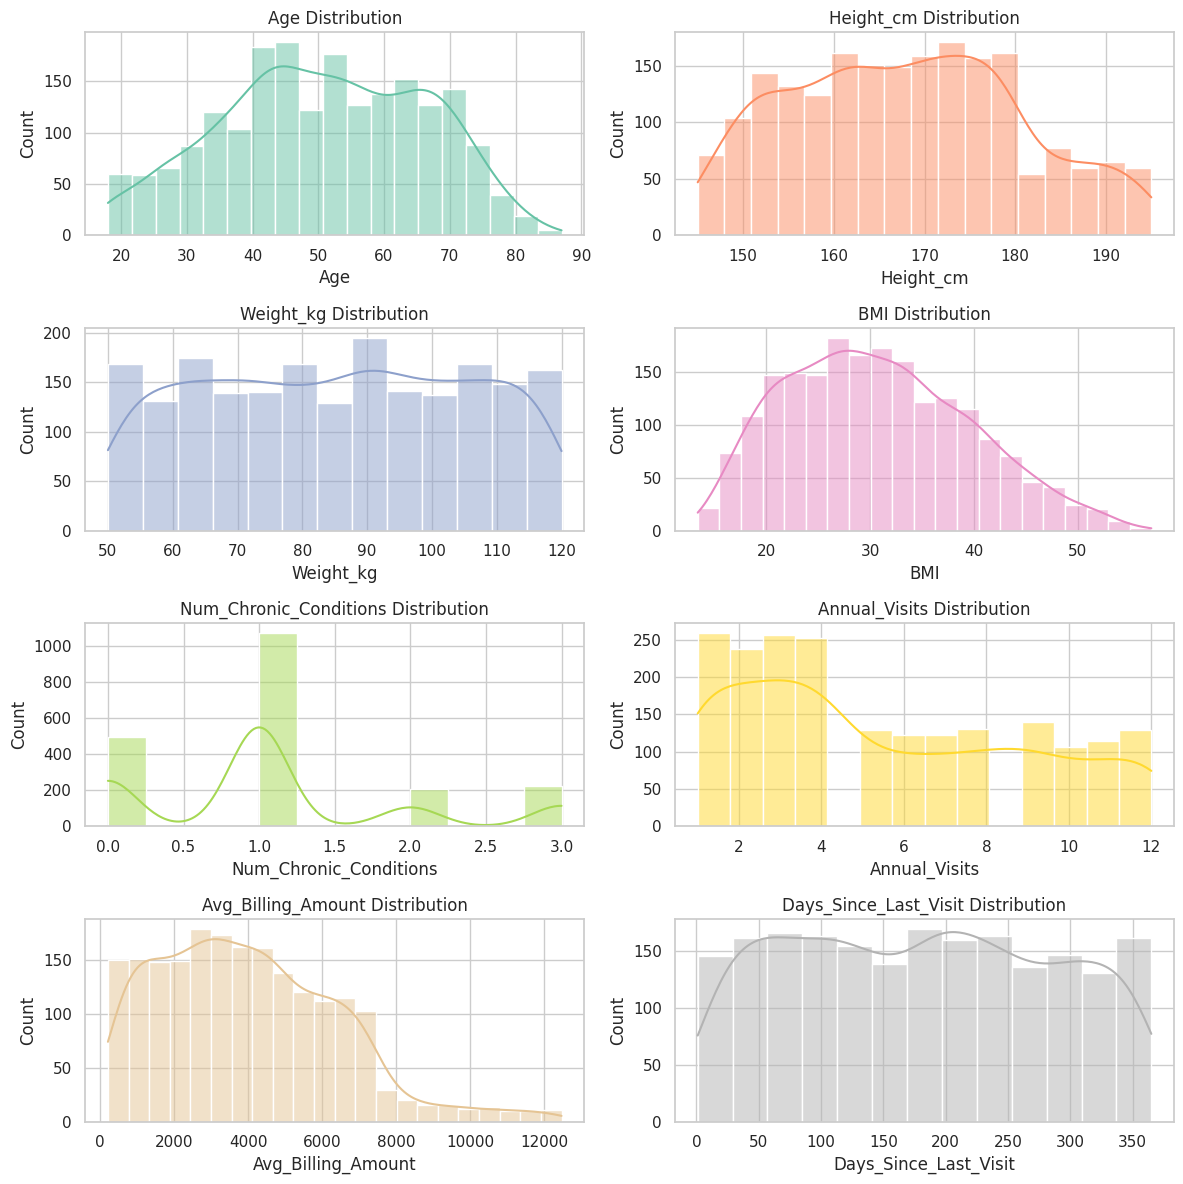

/tmp/ipykernel_432/2536382784.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_432/2536382784.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_432/2536382784.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")


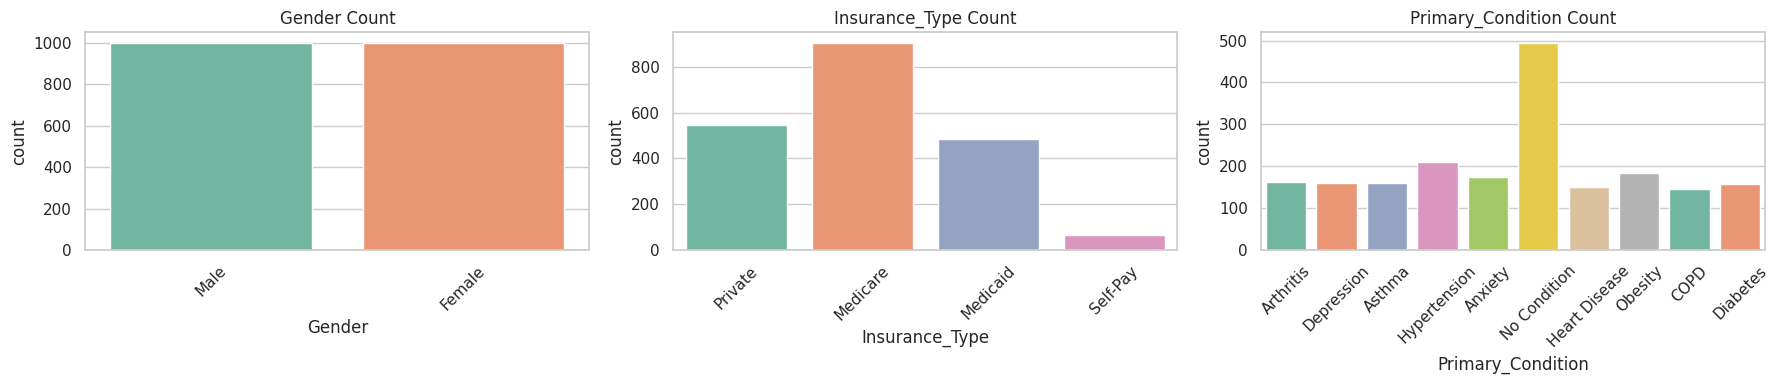

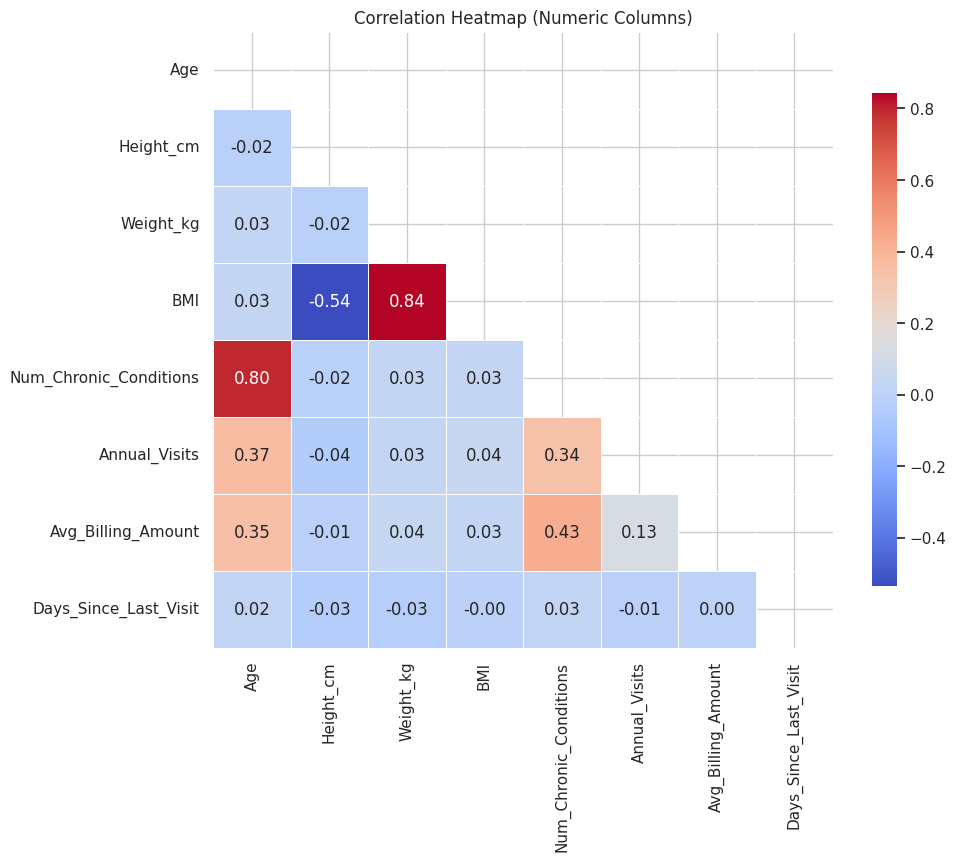

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style and palette
sns.set(style="whitegrid", palette="Set2")

# Select numeric and categorical columns
numeric_cols = [
    'Age', 'Height_cm', 'Weight_kg', 'BMI', 'Num_Chronic_Conditions',
    'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Plot grid of histograms with KDE for numeric columns
n_num = len(numeric_cols)
fig, axes = plt.subplots(nrows=(n_num + 1) // 2, ncols=2, figsize=(12, 3 * ((n_num + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(patient_df_nonan[col], kde=True, ax=axes[i], color=sns.color_palette("Set2")[i % 8])
    axes[i].set_title(f"{col} Distribution")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# Count plots for categorical columns
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=patient_df_nonan[col], ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Count")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric columns
corr = patient_df_nonan[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

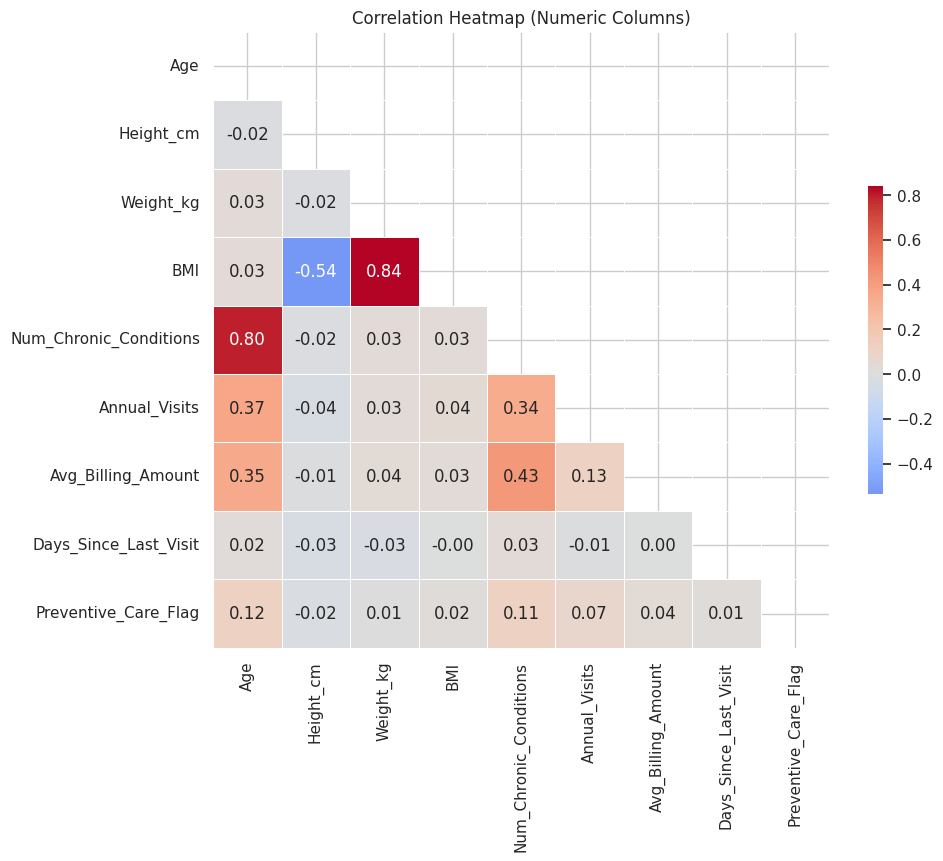

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numeric columns
corr_matrix = patient_df_nonan.select_dtypes(include=[np.number]).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', center=0, square=True, linewidths=.5, cbar_kws={'shrink': .5})

plt.title('Correlation Heatmap (Numeric Columns)')
plt.show()

The correlation heatmap shows how numeric features relate to each other. This helps you understand which features move together and whether any are redundant. Highly correlated features can bias clustering by effectively double-counting the same information.

The correlation heatmap reveals important relationships:

- **Age and Num_Chronic_Conditions** are strongly correlated (r = 0.80). Older patients tend to accumulate more chronic conditions.
- **Weight_kg and BMI** are strongly correlated (r = 0.84), and **Height_cm and BMI** show moderate negative correlation (r = -0.54). Since BMI is derived from height and weight, we will keep only BMI to avoid redundancy.
- **Age, Num_Chronic_Conditions, Annual_Visits, and Avg_Billing_Amount** form a cluster of moderate positive correlations (r = 0.34-0.43). Older, sicker patients visit more and cost more.
- **Days_Since_Last_Visit** shows near-zero correlation with everything else, it captures an independent dimension of patient behavior.

## Clustering

Let's ask the AI to cluster our patients. A natural first instinct, and what most AI assistants will suggest, is **K-Means**.

From the dataframe patient_df_nonan select the numerical variables: Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount, Days_Since_Last_Visit and the categorical variables: Gender, Insurance_Type, and Primary_Condition. Save this new DataFrame in a variable called patients_final_df.

In [16]:
# Select specified numerical and categorical columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]
selected_cols = numerical_cols + categorical_cols

patients_final_df = patient_df_nonan[selected_cols]

# Display the first few rows to verify
patients_final_df.head()

,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Gender,Insurance_Type,Primary_Condition
0,64,50.4,3,7,2995.0,186,Male,Private,Arthritis
1,59,19.0,1,8,1209.0,39,Male,Medicare,Depression
2,58,37.4,1,4,999.0,126,Female,Private,Asthma
3,43,39.8,1,6,5638.5,286,Female,Medicare,Hypertension
4,53,18.3,1,4,5796.0,319,Female,Medicaid,Asthma


Cluster these patients into meaningful segments. Set the hyperparameter sparse_output to False in the OneHotEncoder. Use the most suitable method to choose k and show the process using a graph.

Let's cluster the patients using K-Means. We'll preprocess the data by encoding categorical variables and scaling numerical features. To determine the optimal number of clusters $k$, we'll use the Elbow method and visualize the results.

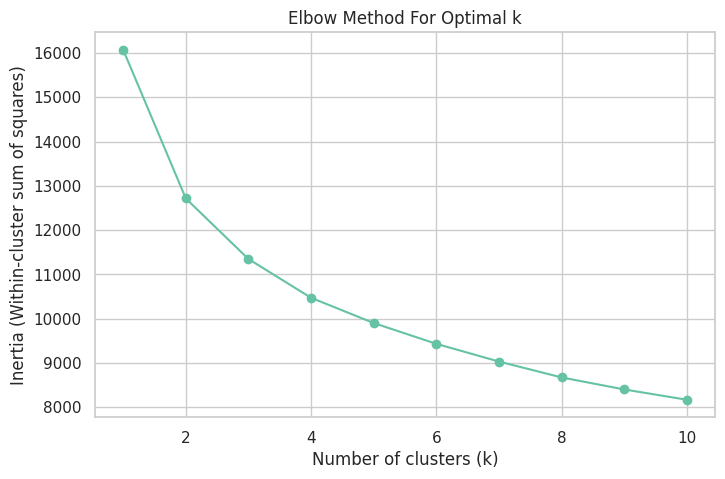

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Define columns
numerical_cols = [
    'Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]
categorical_cols = [
    'Gender', 'Insurance_Type', 'Primary_Condition'
]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(sparse_output=False), categorical_cols)
])

# Prepare data for clustering
X = preprocessor.fit_transform(patients_final_df)

# Elbow method to find optimal k
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

Now fit K-Means with the optimal k on my preprocessed data X. Then use PCA to reduce to 2D and plot the clusters as a scatter plot with plotly.

Let's fit K-Means with the optimal number of clusters (from the elbow method), reduce the data to 2D using PCA, and visualize the clusters using Plotly.

In [18]:
from sklearn.decomposition import PCA
import plotly.express as px
import numpy as np

# Find the elbow point (optimal k) - usually where the inertia starts to decrease more slowly
# For automation, we can use the "knee" point, but here let's pick k=3 as a common choice, or you can adjust as needed
optimal_k = 3  # Change this if you visually identified a different k from the elbow plot

# Fit KMeans with optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})

# Plot with Plotly
fig = px.scatter(
    plot_df, x='PC1', y='PC2', color='Cluster',
    title=f'K-Means Clusters (k={optimal_k}) in 2D PCA Space',
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.show()

Compute feature importance as the standard deviation of each numeric feature across cluster centers.

## Feature Importance via Standard Deviation Across Cluster Centers

We will compute feature importance by clustering the data and then calculating the standard deviation of each numeric feature across the cluster centers. Features with higher standard deviation across centers are considered more important for distinguishing clusters.

In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Select only numeric features for clustering
numeric_features = patients_final_df.select_dtypes(include=[np.number])

# Choose a reasonable number of clusters (e.g., 3)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(numeric_features)

# Get cluster centers
group_centers = pd.DataFrame(kmeans.cluster_centers_, columns=numeric_features.columns)

# Compute standard deviation of each feature across cluster centers
feature_importance = group_centers.std(axis=0)

# Display feature importance
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance

,0
Avg_Billing_Amount,3806.326225
Age,11.678862
Days_Since_Last_Visit,4.967761
Num_Chronic_Conditions,0.953332
Annual_Visits,0.454965
BMI,0.357282


K-Means is the most popular clustering algorithm. K-Means is elegant and fast. But it has a fundamental limitation: it uses Euclidean distance, which only works with numeric data.

In your case, K-Means only found 2 clusters, and the elbow method picked k=2 as "best." But does that really mean your patients only fall into 2 groups?

No, here's what went wrong:

**One-hot encoding**: Converted 3 categorical columns into ~15 binary columns, inflating dimensionality |
**Euclidean distance**: Treats every binary column equally — a 0/1 difference in "Gender_Male" weighs the same as a real numeric difference in Age
**Categorical similarity lost**: "Private" vs "Medicare" insurance are treated as completely unrelated, when they actually carry meaningful similarity structure
**Sparse high-dimensional space**: K-Means struggles in high-dimensional sparse spaces — centroids become meaningless.

We need a distance measure that handles mixed data. Gower distance (1971) was designed precisely for this problem. It computes a distance between 0 and 1 for each feature, using the appropriate method for each data type:

- **Numeric features:** normalized Manhattan distance (range-scaled)
- **Categorical features:** simple matching (0 if same, 1 if different)
- **Final distance:** weighted average across all features

This means each feature contributes equally regardless of type, and we don't need to use one-hot encoding.

With a proper distance matrix in hand, we can use hierarchical (agglomerative) clustering using **weighted linkage**, which works directly on a precomputed distance matrix.

Hierarchical clustering:

- Works with any distance matrix: including our Gower distances.
- Does not require specifying the number of clusters upfront.
- Produces a dendrogram: a tree that shows how patients merge into clusters step by

The K-Means approach didn't work well for the dataset because I have mixed numeric and categorical features. One-hot encoding inflated the dimensionality and Euclidean distance doesn't handle categories properly. Instead, use Gower distance using gower library, installed it if necessary. Use the patients_final_df DataFrame.

Let's compute the Gower distance matrix for your dataset using the `gower` library, which is designed to handle mixed data types (numeric and categorical). This approach avoids the pitfalls of one-hot encoding and Euclidean distance for mixed data.

We'll:
- Install the `gower` library if it's not already installed.
- Compute the Gower distance matrix for the `patients_final_df` DataFrame.

In [21]:
# Install gower if not already installed
import sys
import subprocess

try:
    import gower
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gower'])
    import gower

In [22]:
# Compute Gower distance matrix for patients_final_df
import gower

gower_dist_matrix = gower.gower_matrix(patients_final_df)

# Show the shape and a preview of the distance matrix
print(f"Gower distance matrix shape: {gower_dist_matrix.shape}")
import numpy as np
np.set_printoptions(precision=3, suppress=True)
print(gower_dist_matrix[:5, :5])

Gower distance matrix shape: (2000, 2000)
[[0.    0.455 0.406 0.533 0.603]
 [0.455 0.    0.451 0.437 0.512]
 [0.406 0.451 0.    0.364 0.27 ]
 [0.533 0.437 0.364 0.    0.325]
 [0.603 0.512 0.27  0.325 0.   ]]


Now use agglomerative clustering with average linkage on the Gower distance matrix. Use the silhouette score on the precomputed distance matrix to choose the number of clusters. Use precomputed as metric hyperparameter in AgglomerativeClustering.

Now, let's perform agglomerative clustering using average linkage on the Gower distance matrix. We'll use the silhouette score to determine the optimal number of clusters. The clustering will use the `precomputed` metric, as required for distance matrices like Gower's.

Steps:
- Try different numbers of clusters (e.g., 2 to 10).
- For each, fit AgglomerativeClustering with `average` linkage and `precomputed` metric.
- Compute the silhouette score for each clustering.
- Select the number of clusters with the highest silhouette score.

In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Range of clusters to try
range_n_clusters = range(2, 11)
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',  # Use 'metric' instead of 'affinity'
        linkage='average',
        compute_full_tree=True
    )
    cluster_labels = clusterer.fit_predict(gower_dist_matrix)
    score = silhouette_score(gower_dist_matrix, cluster_labels, metric='precomputed')
    silhouette_scores.append(score)

# Find the best number of clusters
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_n_clusters}")
print(f"Silhouette scores: {silhouette_scores}")

Best number of clusters: 6
Silhouette scores: [np.float32(0.2449744), np.float32(0.18025266), np.float32(0.22623484), np.float32(0.25168622), np.float32(0.26967958), np.float32(0.2526348), np.float32(0.26632142), np.float32(0.25360286), np.float32(0.24595745)]


In [24]:
# Fit final model with the best number of clusters
final_clusterer = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    metric='precomputed',
    linkage='average',
    compute_full_tree=True
)
final_labels = final_clusterer.fit_predict(gower_dist_matrix)

# Add cluster labels to the DataFrame
patients_final_df['Cluster'] = final_labels
patients_final_df.head()

/tmp/ipykernel_432/1077743980.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Age,BMI,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Gender,Insurance_Type,Primary_Condition,Cluster
0,64,50.4,3,7,2995.0,186,Male,Private,Arthritis,1
1,59,19.0,1,8,1209.0,39,Male,Medicare,Depression,5
2,58,37.4,1,4,999.0,126,Female,Private,Asthma,1
3,43,39.8,1,6,5638.5,286,Female,Medicare,Hypertension,4
4,53,18.3,1,4,5796.0,319,Female,Medicaid,Asthma,0


For the agglomerative clustering run above, show me a dendrogram and cluster profiles.

## Dendrogram and Cluster Profiles

Let's visualize the hierarchical clustering using a dendrogram and then summarize the profiles of each cluster based on the features in `patients_final_df`.

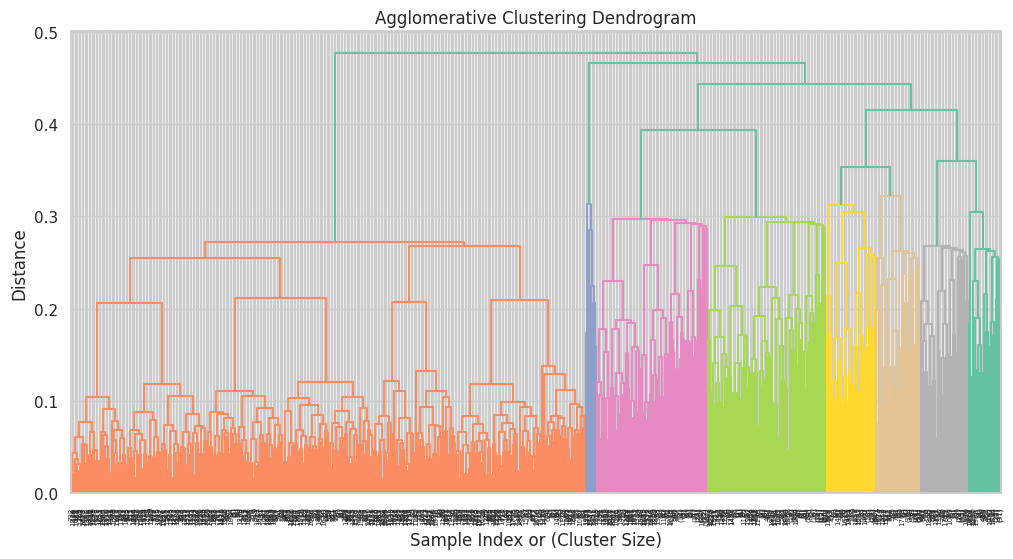

In [25]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Compute linkage matrix for dendrogram (using the same distance matrix and linkage method)
linkage_matrix = sch.linkage(sch.distance.squareform(gower_dist_matrix), method='average')

plt.figure(figsize=(12, 6))
dendro = sch.dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.title('Agglomerative Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

In [26]:
# Cluster profiles: summarize each cluster
cluster_profiles = patients_final_df.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'BMI': ['mean', 'std'],
    'Num_Chronic_Conditions': ['mean', 'std'],
    'Annual_Visits': ['mean', 'std'],
    'Avg_Billing_Amount': ['mean', 'std'],
    'Days_Since_Last_Visit': ['mean', 'std'],
    'Gender': lambda x: x.value_counts().index[0],
    'Insurance_Type': lambda x: x.value_counts().index[0],
    'Primary_Condition': lambda x: x.value_counts().index[0]
})

# Clean up column names
cluster_profiles.columns = ['_'.join(col).strip() for col in cluster_profiles.columns.values]
cluster_profiles.reset_index(inplace=True)
cluster_profiles

,Cluster,Age_mean,Age_std,BMI_mean,BMI_std,Num_Chronic_Conditions_mean,Num_Chronic_Conditions_std,Annual_Visits_mean,Annual_Visits_std,Avg_Billing_Amount_mean,Avg_Billing_Amount_std,Days_Since_Last_Visit_mean,Days_Since_Last_Visit_std,Gender_<lambda>,Insurance_Type_<lambda>,Primary_Condition_<lambda>
0,0,51.070740,7.112561,30.544051,8.422804,1.147910,0.458596,6.498392,3.494581,4317.773312,2224.238221,188.395498,107.308875,Male,Medicaid,Depression
1,1,51.577428,7.183857,31.406299,8.986983,1.170604,0.491803,6.682415,3.451381,3956.598425,2146.305519,182.333333,103.922956,Male,Private,Hypertension
2,2,62.375000,1.597990,22.687500,4.676518,2.750000,0.462910,2.000000,1.069045,8884.812500,2802.505880,131.125000,114.690188,Male,Private,Depression
3,3,30.402020,6.393158,29.886263,8.828389,0.000000,0.000000,2.511111,1.092567,2598.311111,1393.221546,173.494949,103.657132,Male,Medicaid,No Condition
4,4,62.578454,11.367333,32.654333,9.179555,1.655738,0.831303,6.625293,3.442365,4932.629977,2715.172464,186.639344,103.144691,Female,Medicare,Obesity
5,5,62.402116,11.388122,29.358995,8.245123,1.661376,0.828306,6.026455,3.388127,4462.365079,2840.915050,173.243386,105.579487,Male,Medicare,Hypertension


In [32]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# Range of clusters to try
range_n_clusters = range(2, 11)
silhouette_scores = []

print("Calculating silhouette scores for various numbers of clusters...")
for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',  # Use 'metric' as 'affinity' is deprecated
        linkage='average',
        compute_full_tree=True
    )
    cluster_labels = clusterer.fit_predict(gower_dist_matrix)
    score = silhouette_score(gower_dist_matrix, cluster_labels, metric='precomputed')
    silhouette_scores.append(score)
    print(f"  Clusters: {n_clusters}, Silhouette Score: {score:.3f}")

# Find the best number of clusters
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters according to silhouette score: {best_n_clusters}")

# Fit final model with the best number of clusters
final_clusterer = AgglomerativeClustering(
    n_clusters=best_n_clusters,
    metric='precomputed',
    linkage='average',
    compute_full_tree=True
)
final_labels = final_clusterer.fit_predict(gower_dist_matrix)

# Add cluster labels to the DataFrame for further analysis
patients_final_df['Cluster'] = final_labels

print("\nAgglomerative clustering complete. Cluster labels added to 'patients_final_df'.")
print("First 5 rows of patients_final_df with new cluster labels:")
print(patients_final_df.head())

Calculating silhouette scores for various numbers of clusters...
  Clusters: 2, Silhouette Score: 0.245
  Clusters: 3, Silhouette Score: 0.180
  Clusters: 4, Silhouette Score: 0.226
  Clusters: 5, Silhouette Score: 0.252
  Clusters: 6, Silhouette Score: 0.270
  Clusters: 7, Silhouette Score: 0.253
  Clusters: 8, Silhouette Score: 0.266
  Clusters: 9, Silhouette Score: 0.254
  Clusters: 10, Silhouette Score: 0.246

Best number of clusters according to silhouette score: 6

Agglomerative clustering complete. Cluster labels added to 'patients_final_df'.
First 5 rows of patients_final_df with new cluster labels:
   Age   BMI  Num_Chronic_Conditions  Annual_Visits  Avg_Billing_Amount  \
0   64  50.4                       3              7              2995.0   
1   59  19.0                       1              8              1209.0   
2   58  37.4                       1              4               999.0   
3   43  39.8                       1              6              5638.5   
4   53  18

/tmp/ipykernel_432/588533584.py:36: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



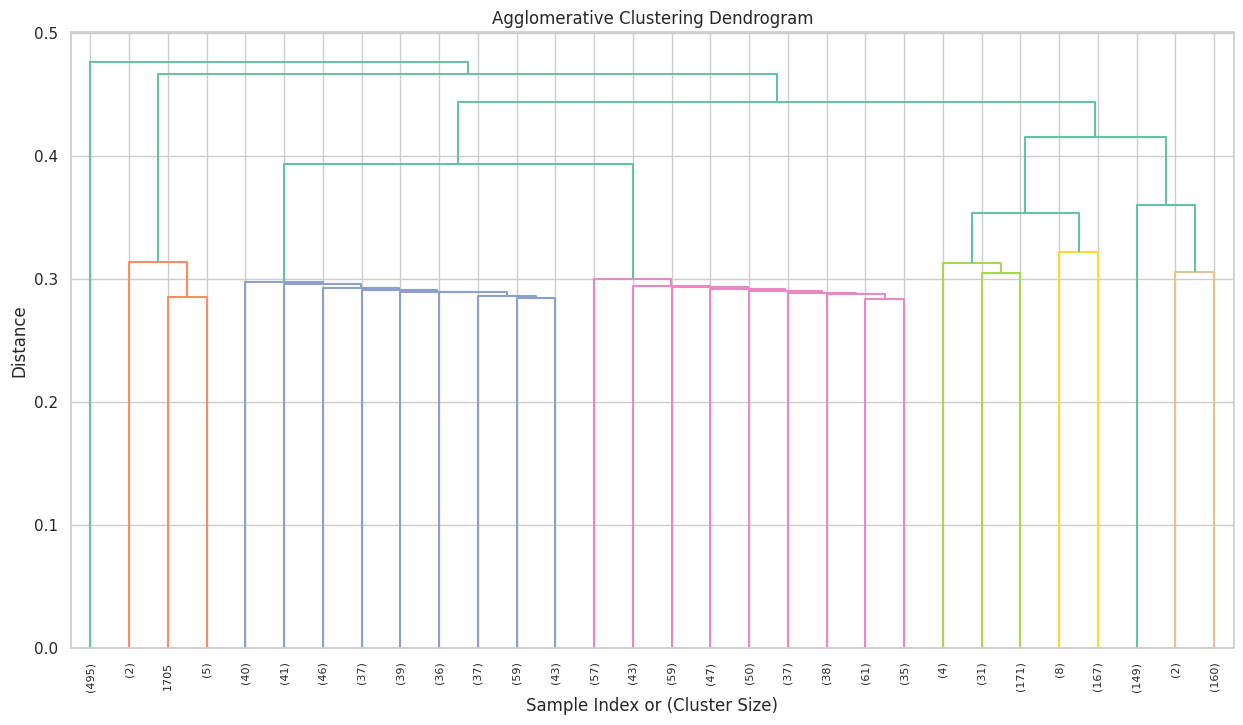


Cluster Profiles:


,Cluster,Age_mean,Age_std,BMI_mean,BMI_std,Num_Chronic_Conditions_mean,Num_Chronic_Conditions_std,Annual_Visits_mean,Annual_Visits_std,Avg_Billing_Amount_mean,Avg_Billing_Amount_std,Days_Since_Last_Visit_mean,Days_Since_Last_Visit_std,Gender_<lambda>,Insurance_Type_<lambda>,Primary_Condition_<lambda>
0,0,51.070740,7.112561,30.544051,8.422804,1.147910,0.458596,6.498392,3.494581,4317.773312,2224.238221,188.395498,107.308875,Male,Medicaid,Depression
1,1,51.577428,7.183857,31.406299,8.986983,1.170604,0.491803,6.682415,3.451381,3956.598425,2146.305519,182.333333,103.922956,Male,Private,Hypertension
2,2,62.375000,1.597990,22.687500,4.676518,2.750000,0.462910,2.000000,1.069045,8884.812500,2802.505880,131.125000,114.690188,Male,Private,Anxiety
3,3,30.402020,6.393158,29.886263,8.828389,0.000000,0.000000,2.511111,1.092567,2598.311111,1393.221546,173.494949,103.657132,Male,Medicaid,No Condition
4,4,62.578454,11.367333,32.654333,9.179555,1.655738,0.831303,6.625293,3.442365,4932.629977,2715.172464,186.639344,103.144691,Female,Medicare,Obesity
5,5,62.402116,11.388122,29.358995,8.245123,1.661376,0.828306,6.026455,3.388127,4462.365079,2840.915050,173.243386,105.579487,Male,Medicare,Hypertension


In [33]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

# --- Dendrogram ---
# Compute linkage matrix for dendrogram (using the same distance matrix and linkage method)
# Ensure gower_dist_matrix is defined and contains float32 or similar numeric type
linkage_matrix = sch.linkage(sch.distance.squareform(gower_dist_matrix), method='average')

plt.figure(figsize=(15, 8))
dendro = sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90., leaf_font_size=8.)
plt.title('Agglomerative Clustering Dendrogram')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.show()

# --- Cluster Profiles ---
# Ensure 'patients_final_df' and 'final_labels' are available from previous steps
# Add cluster labels to the DataFrame if not already done (it was done in gtdoYe8fIHId)
# patients_final_df['Cluster'] = final_labels

cluster_profiles = patients_final_df.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'BMI': ['mean', 'std'],
    'Num_Chronic_Conditions': ['mean', 'std'],
    'Annual_Visits': ['mean', 'std'],
    'Avg_Billing_Amount': ['mean', 'std'],
    'Days_Since_Last_Visit': ['mean', 'std'],
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else 'N/A', # Use mode for categorical
    'Insurance_Type': lambda x: x.mode()[0] if not x.mode().empty else 'N/A',
    'Primary_Condition': lambda x: x.mode()[0] if not x.mode().empty else 'N/A'
})

# Clean up column names
cluster_profiles.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in cluster_profiles.columns.values]
cluster_profiles.reset_index(inplace=True)

print("\nCluster Profiles:")
display(cluster_profiles)


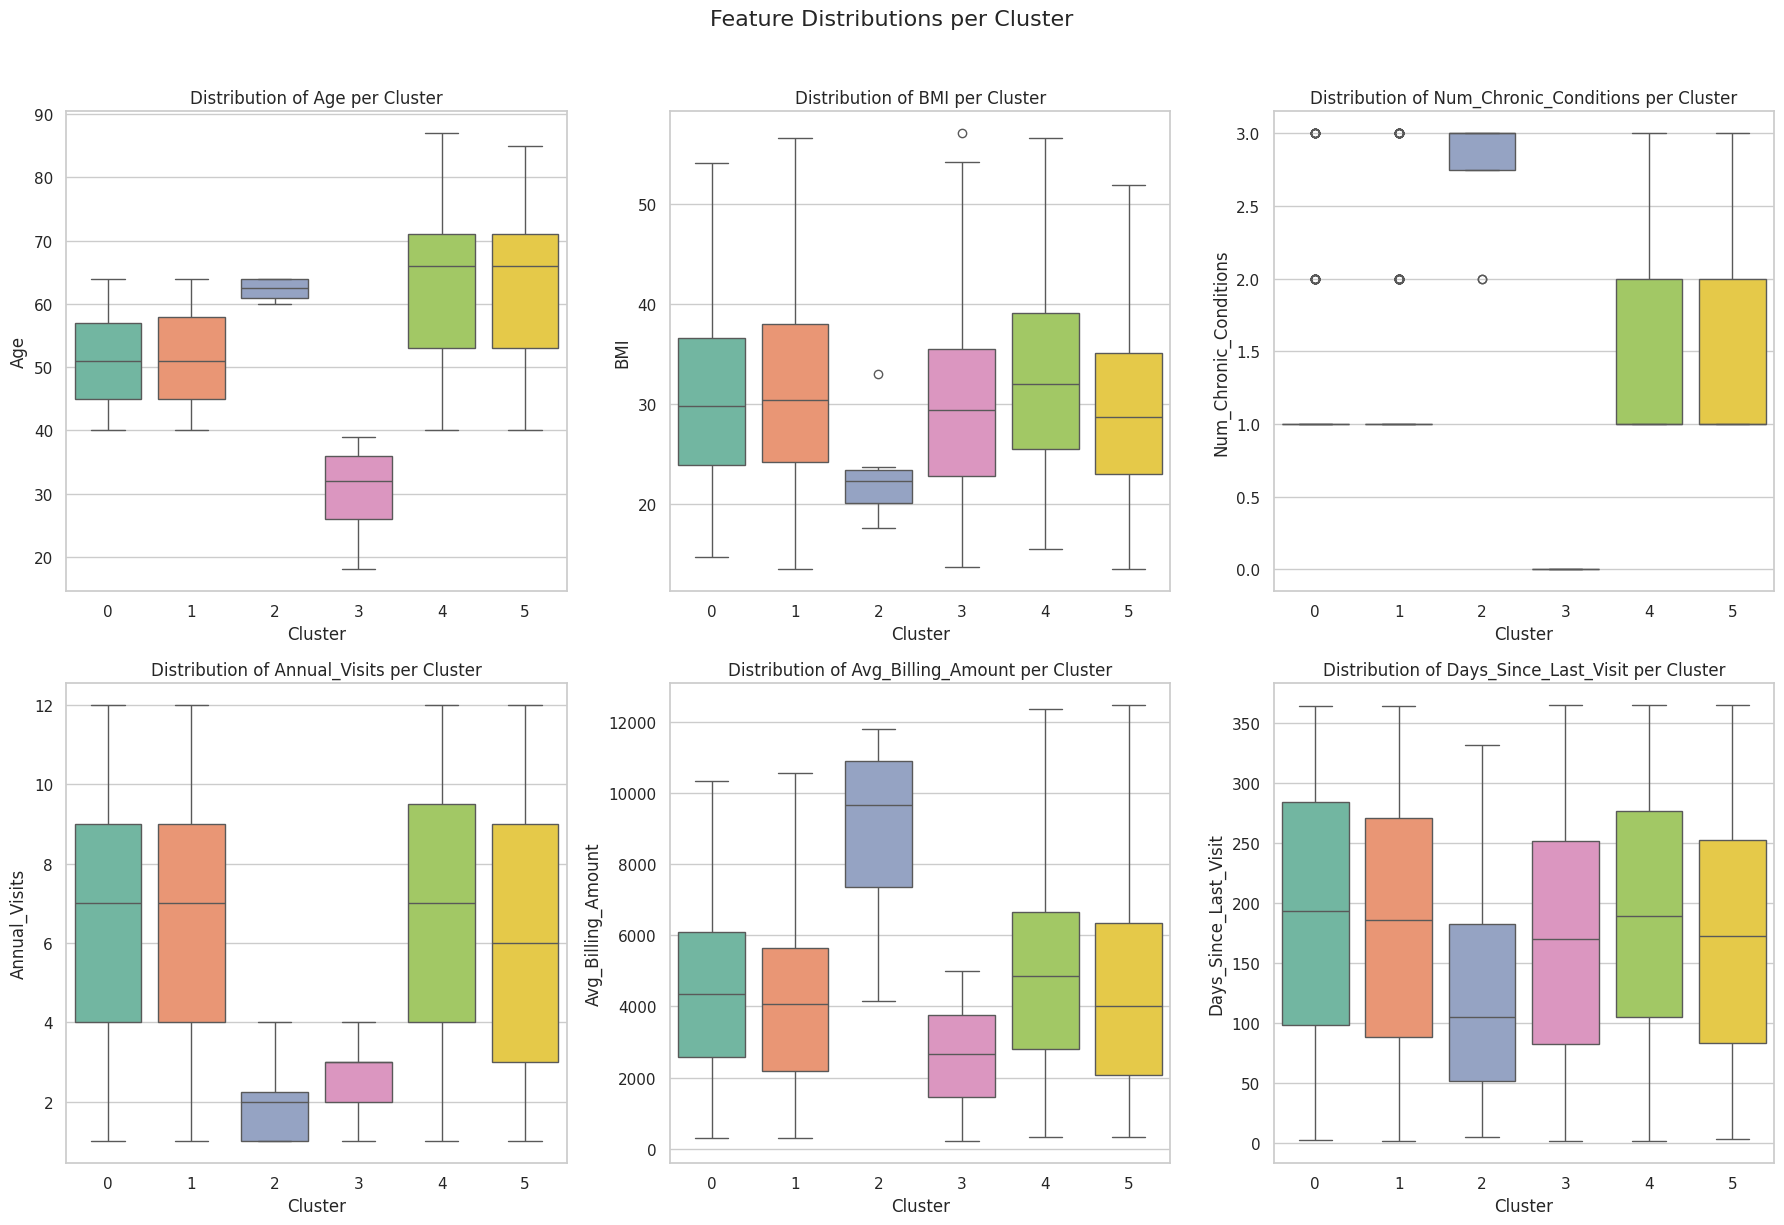

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numeric columns from the original data that need to be plotted
numeric_cols_for_distribution = [
    'Age', 'BMI', 'Num_Chronic_Conditions',
    'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit'
]

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Create a figure and a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Loop through each numeric column and create a box plot
for i, col in enumerate(numeric_cols_for_distribution):
    sns.boxplot(
        x='Cluster',
        y=col,
        data=patients_final_df, # Use the original DataFrame with cluster labels
        palette='Set2',
        hue='Cluster', # Assign the x variable to hue as suggested by the FutureWarning
        legend=False, # Set legend to False for the same effect
        ax=axes[i] # Assign the plot to the correct subplot
    )
    axes[i].set_title(f'Distribution of {col} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

# Add a main title to the entire figure
fig.suptitle('Feature Distributions per Cluster', fontsize=16, y=1.02)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

The dendrogram shows how patients are merged into clusters at each step. The height of each merge represents the distance between the groups being combined. You can "cut" the tree at different heights to get different numbers of clusters.

For understanding what each cluster means, you need to look at the average numeric features and the most common categorical values per cluster to build patient profiles as it showed above.

- The silhouette score plot helps select the optimal number of clusters.
- The dendrogram visualizes the hierarchical clustering structure.
- The table above summarizes the profiles of each cluster, including means and standard deviations for numeric features and value counts for categorical features.

For the cluster_profiles DataFrame, create a 2x3 grid of box plots showing each numeric feature's distribution per cluster. Use the Set2 palette. Add a main title "Feature Distributions per Cluster"

In [28]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# List of numeric features to plot
numeric_features = [
    'Age_mean', 'BMI_mean', 'Num_Chronic_Conditions_mean',
    'Annual_Visits_mean', 'Avg_Billing_Amount_mean', 'Days_Since_Last_Visit_mean'
]

# Prepare subplot grid
fig = sp.make_subplots(rows=2, cols=3, subplot_titles=[
    'Age', 'BMI', 'Num Chronic Conditions',
    'Annual Visits', 'Avg Billing Amount', 'Days Since Last Visit'
])

palette = px.colors.qualitative.Set2

for i, feature in enumerate(numeric_features):
    row = i // 3 + 1
    col = i % 3 + 1
    # Create box plot for each feature
    box = go.Box(
        y=cluster_profiles[feature],
        x=cluster_profiles['Cluster'].astype(str),
        marker_color=palette[i % len(palette)],
        name=feature,
        boxmean=True
    )
    fig.add_trace(box, row=row, col=col)
    fig.update_xaxes(title_text='Cluster', row=row, col=col)
    fig.update_yaxes(title_text=feature.replace('_mean','').replace('_',' '), row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title_text='Feature Distributions per Cluster',
    showlegend=False
)

fig.show()

## Patient Segment Narratives

Based on the cluster profiles above, here are the patient segments you discovered. Let's generate a clear summary for each cluster that a non-technical stakeholder could understand: this is what makes clustering actionable.

For each Cluster in the patient DataFrame, generate a narrative summary. For each cluster show: the number of patients and percentage of total, the mean of each numeric column (Age, BMI, Num_Chronic_Conditions, Annual_Visits, Avg_Billing_Amount, Days_Since_Last_Visit), and the most common value (mode) of each categorical column (Gender, Insurance_Type, Primary_Condition). Format each cluster as a markdown table with an interpretive heading. Use display(Markdown()) to render it.

In [29]:
import pandas as pd
from IPython.display import display, Markdown

# Assuming you have a DataFrame 'cluster_profiles' as described
# Generate a summary for each cluster

def cluster_narrative(profile_df):
    numeric_cols = [
        'Age_mean', 'BMI_mean', 'Num_Chronic_Conditions_mean',
        'Annual_Visits_mean', 'Avg_Billing_Amount_mean', 'Days_Since_Last_Visit_mean'
    ]
    categorical_cols = [
        'Gender_<lambda>', 'Insurance_Type_<lambda>', 'Primary_Condition_<lambda>'
    ]

    # Recalculate total counts from the original patients_final_df
    cluster_counts = patients_final_df['Cluster'].value_counts().sort_index()
    total = cluster_counts.sum()

    for idx, row in profile_df.iterrows():
        cluster = row['Cluster']
        count = cluster_counts.get(cluster, 0) # Get count for current cluster
        percent = 100 * count / total

        # Prepare markdown table
        md = f"### Cluster {cluster}: Segment Overview\n"
        md += f"**Number of patients:** {count} ({percent:.1f}\%)\n\n"
        md += "| Feature | Value |\n|---|---|\n"
        for col in numeric_cols:
            pretty = col.replace('_mean', '').replace('_', ' ')
            md += f"| {pretty} | {row[col]:.2f} |\n"
        for col in categorical_cols:
            pretty = col.replace('_<lambda>', '').replace('_', ' ')
            md += f"| Most common {pretty} | {row[col]} |\n"
        display(Markdown(md))

cluster_narrative(cluster_profiles)

<>:27: SyntaxWarning:

invalid escape sequence '\%'

<>:27: SyntaxWarning:

invalid escape sequence '\%'

/tmp/ipykernel_432/4289495867.py:27: SyntaxWarning:

invalid escape sequence '\%'



### Cluster 0: Segment Overview
**Number of patients:** 311 (15.6\%)

| Feature | Value |
|---|---|
| Age | 51.07 |
| BMI | 30.54 |
| Num Chronic Conditions | 1.15 |
| Annual Visits | 6.50 |
| Avg Billing Amount | 4317.77 |
| Days Since Last Visit | 188.40 |
| Most common Gender | Male |
| Most common Insurance Type | Medicaid |
| Most common Primary Condition | Depression |


### Cluster 1: Segment Overview
**Number of patients:** 381 (19.1\%)

| Feature | Value |
|---|---|
| Age | 51.58 |
| BMI | 31.41 |
| Num Chronic Conditions | 1.17 |
| Annual Visits | 6.68 |
| Avg Billing Amount | 3956.60 |
| Days Since Last Visit | 182.33 |
| Most common Gender | Male |
| Most common Insurance Type | Private |
| Most common Primary Condition | Hypertension |


### Cluster 2: Segment Overview
**Number of patients:** 8 (0.4\%)

| Feature | Value |
|---|---|
| Age | 62.38 |
| BMI | 22.69 |
| Num Chronic Conditions | 2.75 |
| Annual Visits | 2.00 |
| Avg Billing Amount | 8884.81 |
| Days Since Last Visit | 131.12 |
| Most common Gender | Male |
| Most common Insurance Type | Private |
| Most common Primary Condition | Depression |


### Cluster 3: Segment Overview
**Number of patients:** 495 (24.8\%)

| Feature | Value |
|---|---|
| Age | 30.40 |
| BMI | 29.89 |
| Num Chronic Conditions | 0.00 |
| Annual Visits | 2.51 |
| Avg Billing Amount | 2598.31 |
| Days Since Last Visit | 173.49 |
| Most common Gender | Male |
| Most common Insurance Type | Medicaid |
| Most common Primary Condition | No Condition |


### Cluster 4: Segment Overview
**Number of patients:** 427 (21.4\%)

| Feature | Value |
|---|---|
| Age | 62.58 |
| BMI | 32.65 |
| Num Chronic Conditions | 1.66 |
| Annual Visits | 6.63 |
| Avg Billing Amount | 4932.63 |
| Days Since Last Visit | 186.64 |
| Most common Gender | Female |
| Most common Insurance Type | Medicare |
| Most common Primary Condition | Obesity |


### Cluster 5: Segment Overview
**Number of patients:** 378 (18.9\%)

| Feature | Value |
|---|---|
| Age | 62.40 |
| BMI | 29.36 |
| Num Chronic Conditions | 1.66 |
| Annual Visits | 6.03 |
| Avg Billing Amount | 4462.37 |
| Days Since Last Visit | 173.24 |
| Most common Gender | Male |
| Most common Insurance Type | Medicare |
| Most common Primary Condition | Hypertension |


## Actionable Clinical Recommendations per Patient Segment

Based on the detailed cluster profiles, here are actionable clinical recommendations for each identified patient segment:

### Cluster 0: Moderate-Age, Depressed Medicaid Patients
**Profile:** This segment consists of moderate-aged patients (mean Age ~51) with average BMI (~30.5) and a moderate number of chronic conditions (~1.15). They have a higher average annual visits (~6.5) and billing amount (~4317). The most common primary condition is Depression, and they primarily use Medicaid insurance. They also have a relatively high number of days since last visit (~188).
**Recommendation:** Focus on mental health support programs and depression management, coupled with preventative care education tailored for Medicaid beneficiaries to reduce the high days since last visit.

### Cluster 1: Moderate-Age, Hypertensive Private Insurance Patients
**Profile:** Similar in age to Cluster 0 (mean Age ~51.6) and BMI (~31.4), but slightly more chronic conditions (~1.17). They show a similar number of annual visits (~6.7) and average billing (~3956). Hypertension is the most common primary condition, and they predominantly have Private insurance. Days since last visit is moderate (~182).
**Recommendation:** Implement targeted hypertension management programs, emphasize adherence to medication and lifestyle changes, and leverage private insurance benefits for specialized cardiovascular care.

### Cluster 2: Older, Leaner, Depressed Private Insurance Patients with High Billing
**Profile:** This is an older segment (mean Age ~62.4) with a notably lower BMI (~22.7) compared to other clusters and a higher number of chronic conditions (~2.75). They have very low annual visits (~2) but extremely high average billing amounts (~8884), and moderate days since last visit (~131). Depression is the most common condition, and they use Private insurance.
**Recommendation:** Investigate reasons for low visit frequency despite high billing and chronic conditions; consider outreach programs for preventative care and chronic disease management. Offer comprehensive mental health services to address depression.

### Cluster 3: Young, Healthy, No Condition Medicaid Patients
**Profile:** This is the youngest segment (mean Age ~30.4) with an average BMI (~29.9) and importantly, **no chronic conditions**. They have the lowest annual visits (~2.5) and lowest average billing (~2598). They primarily use Medicaid insurance.
**Recommendation:** Focus on preventative health education, healthy lifestyle promotion, and regular check-ups to maintain their healthy status and prevent future chronic conditions. Educate on the benefits of consistent engagement with healthcare.

### Cluster 4: Older, Obese Medicare Patients with Higher Chronic Conditions
**Profile:** This segment consists of older patients (mean Age ~62.6) with a higher average BMI (~32.6) and a higher number of chronic conditions (~1.66). They have a higher number of annual visits (~6.6) and billing amounts (~4932). Obesity is the most common primary condition, and they primarily use Medicare insurance. Days since last visit is moderate (~186).
**Recommendation:** Develop and promote weight management programs and nutritional counseling. Provide robust chronic disease management, particularly for obesity-related conditions, leveraging Medicare benefits for comprehensive care coordination.

### Cluster 5: Older, Hypertensive Medicare Patients
**Profile:** This segment is also older (mean Age ~62.4) with an average BMI (~29.4) and a higher number of chronic conditions (~1.66). They have a moderate number of annual visits (~6) and average billing (~4462). Hypertension is the most common primary condition, and they predominantly use Medicare insurance. Days since last visit is moderate (~173).
**Recommendation:** Implement advanced hypertension management strategies, focusing on medication adherence, blood pressure monitoring, and lifestyle modifications suitable for an older, Medicare-insured population. Ensure continuity of care.

## Predicting the Segment for a New Patient

The clustering is done and our segments are defined. But here's a real-world question: **what happens when a new patient enrolls tomorrow?**

You need to be able to assign them to the right segment without re-running the entire clustering.

The idea is simple: compute the Gower distance from the new patient to every existing patient, then see which cluster they're closest to on average.

I want to predict which cluster a brand-new patient belongs to. Write a function that takes a dictionary of the new patient's features, the original DataFrame, the Gower distance matrix, and the numeric/categorical column lists. For each existing patient, compute the Gower distance to the new patient the same way we did before. Then compute the average distance from the new patient to each cluster. Return the closest cluster and the distances to all clusters. Test it with a sample patient: 55-year-old female, Medicare, Hypertension, BMI 32, 2 chronic conditions, 6 annual visits, $3,500 avg billing, 120 days since last visit.


Let's create a function to predict the cluster for a new patient using Gower distance. We'll:

1. Accept a dictionary of the new patient's features.
2. Compute the Gower distance between the new patient and all existing patients.
3. Calculate the average distance from the new patient to each cluster.
4. Return the closest cluster and the distances to all clusters.

We'll also test this function with a sample patient:
- Age: 55
- Gender: Female
- Insurance_Type: Medicare
- Primary_Condition: Hypertension
- BMI: 32
- Num_Chronic_Conditions: 2
- Annual_Visits: 6
- Avg_Billing_Amount: \$3,500
- Days_Since_Last_Visit: 120

In [31]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def gower_distance(new_patient_dict, df, gower_matrix, numeric_cols, categorical_cols, cluster_labels):
    """
    Compute Gower distance from a new patient to all existing patients, then average by cluster.
    Args:
        new_patient_dict: dict of new patient's features
        df: original DataFrame (without cluster labels)
        gower_matrix: precomputed Gower distance matrix for df (not used for new patient, but kept for API compatibility)
        numeric_cols: list of numeric column names
        categorical_cols: list of categorical column names
        cluster_labels: array-like of cluster assignments for df
    Returns:
        closest_cluster: int, the closest cluster label
        cluster_distances: dict, average distance to each cluster
    """
    # Convert new patient dict to DataFrame
    new_patient_df = pd.DataFrame([new_patient_dict])

    # Ensure new_patient_df has all the columns from df, filling missing with NaN if necessary
    # This is important for scaler.transform to work correctly if new_patient_dict is missing some cols
    # Or, more robustly, ensure new_patient_dict keys match df's numeric and categorical columns exactly
    # For this example, we assume new_patient_dict contains all relevant columns.

    # Numeric part: min-max scale using df's min/max
    scaler = MinMaxScaler()
    scaler.fit(df[numeric_cols])
    df_num_scaled = scaler.transform(df[numeric_cols])
    new_num_scaled = scaler.transform(new_patient_df[numeric_cols])

    # Categorical part: 0 if same, 1 if different
    # The comparison needs to be broadcast correctly. For a single new patient, we can iterate or expand dims.
    cat_dist_list = []
    for col in categorical_cols:
        # Compare new patient's category with each existing patient's category
        cat_dist_list.append((df[col].values != new_patient_df[col].iloc[0]).astype(float))
    cat_dist = np.stack(cat_dist_list, axis=1) # Stack to get shape (n_samples, n_categorical_features)

    # Numeric distance: abs diff (already done for scaled values)
    num_dist = np.abs(df_num_scaled - new_num_scaled)

    # Combine: average over all features
    # Check if number of features in num_dist and cat_dist match numeric_cols and categorical_cols lengths
    if num_dist.shape[1] + cat_dist.shape[1] != len(numeric_cols) + len(categorical_cols):
        raise ValueError("Mismatch in feature counts for distance calculation.")

    all_dist = np.concatenate([num_dist, cat_dist], axis=1)
    gower_distances = all_dist.mean(axis=1)

    # Average by cluster
    cluster_distances = {}
    for cluster in np.unique(cluster_labels):
        cluster_distances[cluster] = gower_distances[cluster_labels == cluster].mean()
    closest_cluster = min(cluster_distances, key=cluster_distances.get)
    return closest_cluster, cluster_distances

# Example: Assume you have cluster labels from previous clustering
# For demonstration, let's use patients_final_df as the base DataFrame
df_for_clustering = patients_final_df.copy()
cluster_labels = final_labels # Use the actual final_labels from AgglomerativeClustering

# Define column lists (ensure they match the columns in patients_final_df)
numeric_cols = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit']
categorical_cols = ['Gender', 'Insurance_Type', 'Primary_Condition']

# Sample patient (ensure values match expected types and categories)
sample_patient = {
    'Age': 55,
    'Gender': 'Female',  # Use actual string categories
    'Insurance_Type': 'Medicare',  # Use actual string categories
    'Primary_Condition': 'Hypertension',  # Use actual string categories
    'BMI': 32,
    'Num_Chronic_Conditions': 2,
    'Annual_Visits': 6,
    'Avg_Billing_Amount': 3500,
    'Days_Since_Last_Visit': 120
}

# Dummy Gower matrix (not used in function, but required by signature, can be an empty array if not actually needed)
gower_matrix = np.zeros((len(df_for_clustering), len(df_for_clustering)))

closest_cluster, cluster_distances = gower_distance(
    sample_patient, df_for_clustering, gower_matrix, numeric_cols, categorical_cols, cluster_labels
)

from IPython.display import display
print(f"Closest cluster: {closest_cluster}")
display(cluster_distances)

Closest cluster: 4


{np.int64(0): np.float64(0.4122696343645364),
 np.int64(1): np.float64(0.40446264636037593),
 np.int64(2): np.float64(0.49943964894179604),
 np.int64(3): np.float64(0.4672146161675059),
 np.int64(4): np.float64(0.24819628045761774),
 np.int64(5): np.float64(0.35201719962384437)}

# Summary: Patient Segmentation in Healthcare

## Executive Summary: Patient Segmentation in Healthcare

This project successfully segmented healthcare patients into 6 distinct groups using advanced machine learning, moving beyond traditional methods to leverage **Gower distance** and **Agglomerative Hierarchical Clustering** for mixed data types. This approach provided accurate and actionable patient profiles.

Key outcomes include:

*   **Robust Data Foundations**: Thorough data cleaning and exploratory analysis ensured high-quality input for modeling.
*   **Meaningful Segmentation**: Identification of 6 distinct patient segments, characterized by detailed profiles of demographic, clinical, and financial behaviors.
*   **Practical Application**: Development of a system to assign new patients to their most relevant segment, enabling targeted interventions and strategic resource allocation.

This work demonstrates how sophisticated analytics, thoughtfully applied, can deliver critical insights for strategic healthcare management and patient care optimization.

## Key Takeaways

*   **Data exploration is foundational**: Essential for effective preprocessing and insights.
*   **AI augments, but expertise validates**: AI speeds up tasks, but domain knowledge is crucial for correctness.
*   **Algorithm choice is paramount**: Selecting the right algorithm (e.g., Gower distance for mixed data) is key to accurate results.
*   **Actionable insights drive value**: Segmentation is only valuable when translated into clear, interpretable patient narratives for decision-makers.